# Anticipating Currency Meltdowns: Regime Detection and Dynamic EM Carry (Real-Data Edition)

Rebuild of the carry-regime study on real, licensed-quality data: `fx_rates.parquet`
(monthly FX, 1957-2026, many countries) and `interest_rates.parquet` (daily policy
rates, various start dates through 2026). **Both files must sit next to this
notebook** for Section 2 to run.

**Universe change from the earlier hand-reconstructed version:** Thailand, South
Korea, Brazil and Malaysia are not present in either file. What IS present with
genuine daily rate history is **Turkey, South Africa, Mexico, India, Argentina,
Colombia and Chile** — arguably a more demanding test set, since it includes two
of the most famous sustained-depreciation currencies in emerging markets (TRY, ARS).

**Headline result, stated up front:** with real data, a longer sample (2002-2025),
and this currency set, the earlier finding **reverses**. Always-on carry beats
every regime-gated variant on point estimate, and a block bootstrap shows this
is more likely than not to be a genuine reversal, not noise. Section 8 shows why:
the regime detector protects well against Argentina's episodic crises, and not at
all against Turkey's continuous structural depreciation — two different
phenomena that a single pooled "calm vs. turbulent" signal cannot both handle.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from hmmlearn.hmm import GaussianHMM

plt.rcParams.update({
    'figure.dpi': 150, 'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'font.family': 'DejaVu Sans',
})
GREY, BLUE, ORANGE, GREEN, RED = '#999999', '#4C72B0', '#DD8452', '#7FB29A', '#C4544E'

COUNTRIES = ["Turkey", "South Africa", "Mexico", "India", "Argentina", "Colombia", "Chile"]
CCY_MAP = {"Turkey":"TRY","South Africa":"ZAR","Mexico":"MXN","India":"INR",
           "Argentina":"ARS","Colombia":"COP","Chile":"CLP"}
FX_COUNTRY_FILTER = {"ZAR": "South Africa", "USD": "United States"}
START, END = "2002-03-01", "2025-06-01"
CUTOFF = "2015-01-01"
np.random.seed(7)


## 2. Load the real data

FX: monthly, local currency per USD. Rates: daily policy rates, resampled to
month-end. Both supplied by Federico; not re-derived or approximated.

In [2]:
fx_raw = pd.read_parquet("fx_rates.parquet")
ir_raw = pd.read_parquet("interest_rates.parquet")

fx_panel = {}
for country, ccy in CCY_MAP.items():
    sub = fx_raw[fx_raw["currency"] == ccy]
    if ccy in FX_COUNTRY_FILTER:
        sub = sub[sub["country"] == FX_COUNTRY_FILTER[ccy]]
    sub = sub.sort_values("date").drop_duplicates("date").set_index("date")
    fx_panel[country] = sub["fx_rate_per_usd"]
fx_panel = pd.DataFrame(fx_panel)
fx_panel.index = fx_panel.index + pd.offsets.MonthBegin(0)
fx_panel = fx_panel.loc[START:END]

rate_panel = {}
for country, ccy in CCY_MAP.items():
    sub = ir_raw[ir_raw["currency"] == ccy].sort_values("date").drop_duplicates("date").set_index("date")
    rate_panel[country] = sub["policy_rate_pct"].resample("MS").last()
usd_sub = ir_raw[ir_raw["currency"] == "USD"].sort_values("date").drop_duplicates("date").set_index("date")
rate_panel["USD"] = usd_sub["policy_rate_pct"].resample("MS").last()
rate_panel = pd.DataFrame(rate_panel).loc[START:END].ffill()

print("FX panel:", fx_panel.shape, fx_panel.index.min().date(), "to", fx_panel.index.max().date())
print("Rate panel:", rate_panel.shape, rate_panel.index.min().date(), "to", rate_panel.index.max().date())
print("Nulls -- FX:", fx_panel.isnull().sum().sum(), " Rates:", rate_panel.isnull().sum().sum())


FX panel: (280, 7) 2002-03-01 to 2025-06-01
Rate panel: (280, 8) 2002-03-01 to 2025-06-01
Nulls -- FX: 0  Rates: 0


## 3. Carry excess returns and a sanity check

Same construction as before: `rx = (i_local - i_usd) - delta_s`, monthly.

In [3]:
log_fx = np.log(fx_panel[COUNTRIES])
d_s = log_fx.diff()
i_star = rate_panel[COUNTRIES] / 100 / 12
i_usd = rate_panel["USD"] / 100 / 12
rx = i_star.sub(i_usd, axis=0) - d_s
rx = rx.dropna(how="all")

ann_ret, ann_vol = rx.mean()*12, rx.std()*np.sqrt(12)
print("Full-sample (2002-2025) static per-currency carry:")
for c in COUNTRIES:
    print(f"  {c:14s} ret={ann_ret[c]*100:7.2f}%  vol={ann_vol[c]*100:6.2f}%  Sharpe={ann_ret[c]/ann_vol[c]:.2f}")


Full-sample (2002-2025) static per-currency carry:
  Turkey         ret=   0.67%  vol= 17.04%  Sharpe=0.04
  South Africa   ret=   3.52%  vol= 16.18%  Sharpe=0.22
  Mexico         ret=   1.46%  vol= 11.44%  Sharpe=0.13
  India          ret=   2.35%  vol=  7.02%  Sharpe=0.33
  Argentina      ret=  -1.27%  vol= 22.10%  Sharpe=-0.06
  Colombia       ret=   1.88%  vol= 13.18%  Sharpe=0.14
  Chile          ret=   0.91%  vol= 12.08%  Sharpe=0.08


## 4. FX backdrop: what the regime detector is actually up against

Turkey and Argentina depreciated by orders of magnitude over 2015-2025 -- this
is the context for every result below.

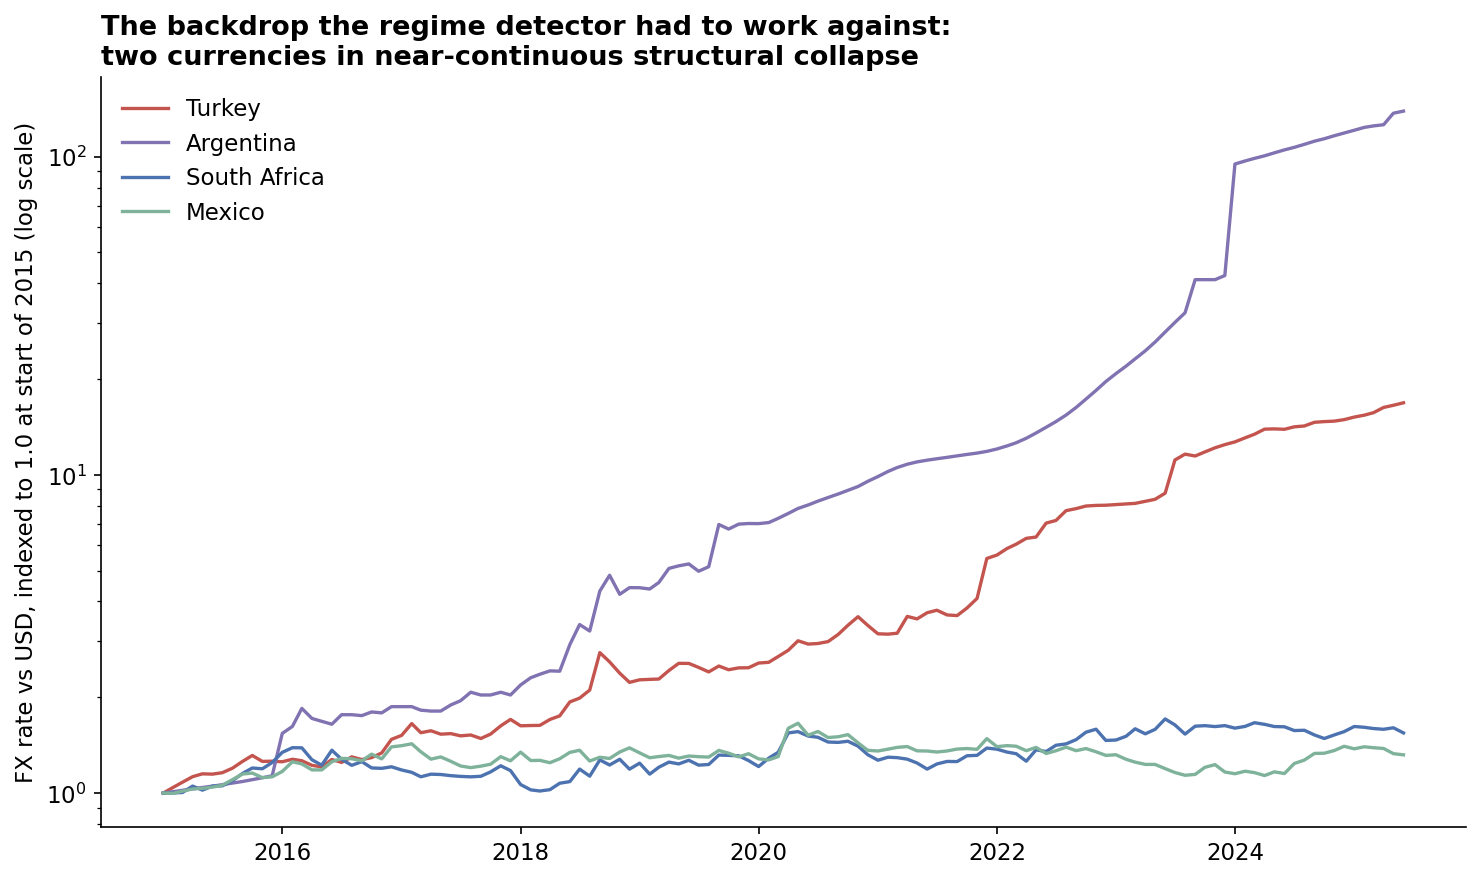

Turkey: 1584.6% weaker vs USD, 2015-2025
Argentina: 13807.2% weaker vs USD, 2015-2025


In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
fx_test = fx_panel.loc[CUTOFF:]
for c, col in [("Turkey", RED), ("Argentina", "#8172B2"), ("South Africa", BLUE), ("Mexico", GREEN)]:
    series = fx_test[c] / fx_test[c].iloc[0]
    ax.plot(series.index, series.values, label=c, color=col, linewidth=1.6)
ax.set_yscale("log")
ax.set_ylabel("FX rate vs USD, indexed to 1.0 at start of 2015 (log scale)")
ax.set_title("The backdrop the regime detector had to work against:\ntwo currencies in near-continuous structural collapse", loc="left", fontsize=13)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(loc="upper left", frameon=False)
plt.tight_layout()
plt.savefig("fig1_fx_collapse.png", bbox_inches="tight")
plt.show()

for c in ["Turkey", "Argentina"]:
    start_v, end_v = fx_test[c].iloc[0], fx_test[c].iloc[-1]
    print(f"{c}: {(end_v/start_v - 1)*100:.1f}% weaker vs USD, 2015-2025")


## 5. Regime features and train/test split

In [5]:
port = rx.mean(axis=1)
disp = rx.std(axis=1)
feat = pd.DataFrame({"port_ret": port, "vol3": port.rolling(3).std(),
                      "disp3": disp.rolling(3).mean()}).dropna()
train_feat = feat[feat.index < CUTOFF]
test_feat = feat[feat.index >= CUTOFF]
print(f"Train: {train_feat.index.min().date()} to {train_feat.index.max().date()} ({len(train_feat)} months)")
print(f"Test:  {test_feat.index.min().date()} to {test_feat.index.max().date()} ({len(test_feat)} months)")


Train: 2002-06-01 to 2014-12-01 (151 months)
Test:  2015-01-01 to 2025-06-01 (126 months)


## 6. Three regime-detection methods (unchanged methodology from the prior version)

In [6]:
def fit_gmm(train_feat, seed=7):
    X = train_feat[["vol3", "disp3"]].values
    mu, sigma = X.mean(axis=0), X.std(axis=0)
    Xs = (X - mu) / sigma
    gmm = GaussianMixture(n_components=2, covariance_type="full", random_state=seed, n_init=10)
    gmm.fit(Xs)
    turb_idx = int(np.argmax(gmm.means_[:, 0]))
    return gmm, mu, sigma, turb_idx

def gmm_predict(gmm, mu, sigma, turb_idx, feat):
    X = feat[["vol3", "disp3"]].values
    Xs = (X - mu) / sigma
    return pd.Series(gmm.predict_proba(Xs)[:, turb_idx], index=feat.index)

def fit_hmm(train_feat, seed=7):
    X = train_feat[["vol3", "disp3"]].values
    mu, sigma = X.mean(axis=0), X.std(axis=0)
    Xs = (X - mu) / sigma
    hmm = GaussianHMM(n_components=2, covariance_type="full", n_iter=200, random_state=seed)
    hmm.fit(Xs)
    turb_idx = int(np.argmax(hmm.means_[:, 0]))
    return hmm, mu, sigma, turb_idx

def hmm_predict(hmm, mu, sigma, turb_idx, feat):
    X = feat[["vol3", "disp3"]].values
    Xs = (X - mu) / sigma
    return pd.Series(hmm.predict_proba(Xs)[:, turb_idx], index=feat.index)

def vol_managed_weight(feat, target_vol=None):
    vol = feat["vol3"]
    target = target_vol if target_vol is not None else vol.median()
    return (target / vol).clip(upper=2.0).clip(lower=0.0)

gmm, gmu, gsigma, gturb = fit_gmm(train_feat)
hmm, hmu, hsigma, hturb = fit_hmm(train_feat)
gmm_proba = gmm_predict(gmm, gmu, gsigma, gturb, feat)
hmm_proba = hmm_predict(hmm, hmu, hsigma, hturb, feat)
print(f"GMM: {(gmm_proba[train_feat.index]>0.5).mean()*100:.1f}% of TRAIN labeled turbulent")
print(f"HMM: {(hmm_proba[train_feat.index]>0.5).mean()*100:.1f}% of TRAIN labeled turbulent")


GMM: 37.7% of TRAIN labeled turbulent
HMM: 36.4% of TRAIN labeled turbulent


## 7. Backtest all four variants, strictly out-of-sample (2015-2025)

In [7]:
def backtest_variant(rx, position, cost_bps=15.0):
    port = rx.mean(axis=1)
    pos = position.reindex(port.index).shift(1).fillna(0)
    pos_change = pos.diff().abs().fillna(0)
    return pos * port - pos_change * cost_bps / 10000

def perf_stats(r, freq=12):
    r = r.dropna(); n = len(r)
    if n < 6:
        return dict(n=n, cagr=np.nan, sharpe=np.nan, maxdd=np.nan, vol=np.nan)
    cum = (1 + r).cumprod(); years = n / freq
    cagr = (1 + (cum.iloc[-1] - 1)) ** (1 / years) - 1
    vol = r.std() * np.sqrt(freq)
    sharpe = (r.mean() * freq) / vol if vol > 0 else np.nan
    maxdd = (cum / cum.cummax() - 1).min()
    return dict(n=n, cagr=cagr, sharpe=sharpe, maxdd=maxdd, vol=vol)

always_on = pd.Series(1.0, index=rx.index)
gmm_gate = (gmm_proba <= 0.5).astype(float).reindex(rx.index)
hmm_gate = (hmm_proba <= 0.5).astype(float).reindex(rx.index)
vw = vol_managed_weight(feat).reindex(rx.index)
variants = {"always_on": always_on, "gmm_gated": gmm_gate, "hmm_gated": hmm_gate, "vol_managed": vw}
colors = {"always_on": GREY, "gmm_gated": BLUE, "hmm_gated": ORANGE, "vol_managed": GREEN}

print(f"{'Variant':14s} {'CAGR':>8s} {'Sharpe':>8s} {'MaxDD':>8s} {'Vol':>8s}")
for name, pos in variants.items():
    strat = backtest_variant(rx, pos)
    st = perf_stats(strat[strat.index >= CUTOFF])
    print(f"{name:14s} {st['cagr']*100:7.2f}% {st['sharpe']:8.2f} {st['maxdd']*100:7.1f}% {st['vol']*100:6.1f}%")

print("\n=== Cost sensitivity (OOS Sharpe) ===")
for cost in [0, 15, 30]:
    row = []
    for name, pos in variants.items():
        strat = backtest_variant(rx, pos, cost_bps=cost)
        st = perf_stats(strat[strat.index >= CUTOFF])
        row.append(f"{name}={st['sharpe']:.2f}")
    print(f"cost={cost:2d}bps:", "  ".join(row))


Variant            CAGR   Sharpe    MaxDD      Vol
always_on        -2.34%    -0.21   -24.4%    9.2%
gmm_gated        -1.75%    -0.31   -20.5%    5.2%
hmm_gated        -1.24%    -0.26   -14.0%    4.4%
vol_managed      -3.46%    -0.30   -35.9%   10.0%

=== Cost sensitivity (OOS Sharpe) ===
cost= 0bps: always_on=-0.21  gmm_gated=-0.24  hmm_gated=-0.23  vol_managed=-0.24
cost=15bps: always_on=-0.21  gmm_gated=-0.31  hmm_gated=-0.26  vol_managed=-0.30
cost=30bps: always_on=-0.21  gmm_gated=-0.38  hmm_gated=-0.29  vol_managed=-0.37


## 8. The mechanism: why the pooled signal helps Argentina and not Turkey

Split out-of-sample carry return by GMM regime, per currency.

In [8]:
test = rx[rx.index >= CUTOFF]
calm_mask = (gmm_proba[test.index] <= 0.5)
print(f"{'Country':14s} {'Calm':>8s} {'Turbulent':>10s} {'Full':>8s}")
for c in COUNTRIES:
    calm_r = test.loc[calm_mask, c].mean() * 100
    turb_r = test.loc[~calm_mask, c].mean() * 100
    full_r = test[c].mean() * 100
    print(f"{c:14s} {calm_r:7.2f}% {turb_r:9.2f}% {full_r:7.2f}%")


Country            Calm  Turbulent     Full
Turkey           -0.52%     -1.29%   -0.92%
South Africa     -0.44%      0.36%   -0.03%
Mexico            0.29%      0.02%    0.15%
India            -0.03%      0.16%    0.07%
Argentina         1.03%     -1.18%   -0.11%
Colombia         -0.62%      0.34%   -0.12%
Chile            -0.21%     -0.13%   -0.17%


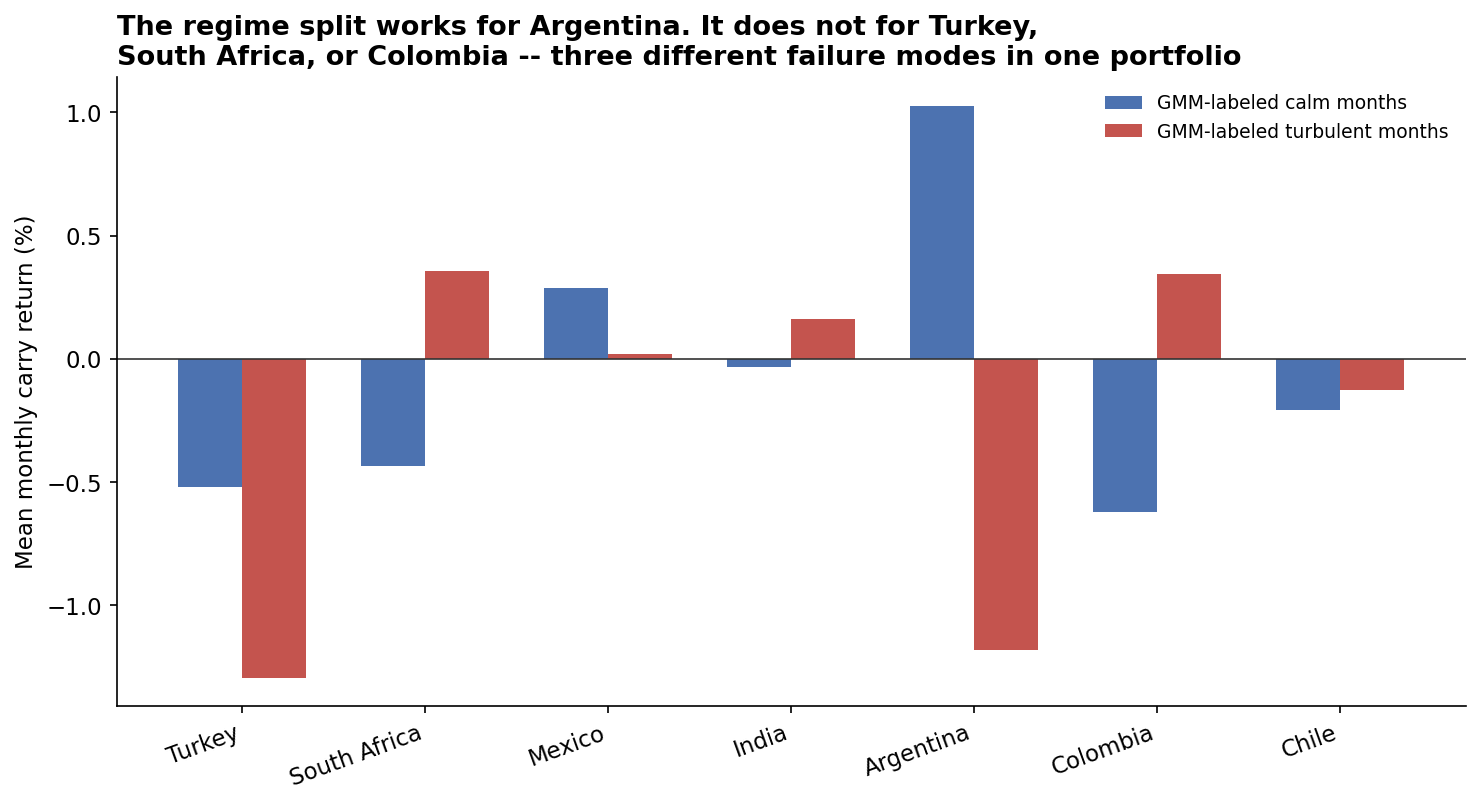

In [9]:
calm_rets = [test.loc[calm_mask, c].mean() * 100 for c in COUNTRIES]
turb_rets = [test.loc[~calm_mask, c].mean() * 100 for c in COUNTRIES]
x = np.arange(len(COUNTRIES)); w = 0.35
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(x - w/2, calm_rets, w, label="GMM-labeled calm months", color=BLUE)
ax.bar(x + w/2, turb_rets, w, label="GMM-labeled turbulent months", color=RED)
ax.axhline(0, color="#333333", linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(COUNTRIES, rotation=20, ha="right")
ax.set_ylabel("Mean monthly carry return (%)")
ax.set_title("The regime split works for Argentina. It does not for Turkey,\nSouth Africa, or Colombia -- three different failure modes in one portfolio", loc="left", fontsize=13)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(frameon=False, loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig("fig2_regime_conditional.png", bbox_inches="tight")
plt.show()


## 9. Robustness: drop Turkey and Argentina

If the 7-currency portfolio's negative Sharpe is being driven by two extreme,
sustained-depreciation currencies, a 'tamer' 5-currency portfolio should look
much less bad.

In [10]:
tame = ["South Africa", "Mexico", "India", "Colombia", "Chile"]
port_tame = rx[tame].mean(axis=1)
tame_oos = port_tame[port_tame.index >= CUTOFF]
tame_sharpe = (tame_oos.mean()*12) / (tame_oos.std()*np.sqrt(12))
print(f"Always-on, 5-currency (ex-TRY, ex-ARS) OOS Sharpe: {tame_sharpe:.3f}")
print(f"Always-on, full 7-currency OOS Sharpe (for comparison): "
      f"{(oos_ao := backtest_variant(rx, always_on)[backtest_variant(rx, always_on).index>=CUTOFF]).mean()*12 / (oos_ao.std()*np.sqrt(12)):.3f}")


Always-on, 5-currency (ex-TRY, ex-ARS) OOS Sharpe: -0.027
Always-on, full 7-currency OOS Sharpe (for comparison): -0.210


## 10. Adversarial check: block bootstrap (does the reversal survive?)

In [11]:
BLOCK, N_DRAW = 6, 2000
rng = np.random.default_rng(11)

oos_mat = {}
for name, pos in variants.items():
    strat = backtest_variant(rx, pos)
    oos_mat[name] = strat[strat.index >= CUTOFF].values
names = list(oos_mat.keys())
mat = np.column_stack([oos_mat[n] for n in names])

def block_bootstrap_sample(mat, block, rng):
    n = mat.shape[0]; n_blocks = int(np.ceil(n / block))
    starts = rng.integers(0, n - block + 1, size=n_blocks)
    idx = np.concatenate([np.arange(s, s + block) for s in starts])[:n]
    return mat[idx]

boot = np.zeros((N_DRAW, len(names)))
for d in range(N_DRAW):
    sample = block_bootstrap_sample(mat, BLOCK, rng)
    m, s = sample.mean(axis=0) * 12, sample.std(axis=0) * np.sqrt(12)
    boot[d] = m / s

print("=== 95% bootstrap CI (point estimate first) ===")
for i, n in enumerate(names):
    lo, hi = np.percentile(boot[:, i], [2.5, 97.5])
    point = mat[:, i].mean() / mat[:, i].std() * np.sqrt(12)
    print(f"  {n:14s} point={point:.2f}  95% CI=[{lo:.2f}, {hi:.2f}]")

ai, gi, hi_, vi = [names.index(x) for x in ["always_on", "gmm_gated", "hmm_gated", "vol_managed"]]
print(f"\nP(GMM > always_on)         = {(boot[:,gi] > boot[:,ai]).mean():.3f}")
print(f"P(HMM > always_on)         = {(boot[:,hi_] > boot[:,ai]).mean():.3f}")
print(f"P(vol_managed > always_on) = {(boot[:,vi] > boot[:,ai]).mean():.3f}")
print(f"P(HMM > GMM)               = {(boot[:,hi_] > boot[:,gi]).mean():.3f}")


=== 95% bootstrap CI (point estimate first) ===
  always_on      point=-0.21  95% CI=[-0.67, 0.31]
  gmm_gated      point=-0.31  95% CI=[-0.83, 0.32]
  hmm_gated      point=-0.26  95% CI=[-0.76, 0.44]
  vol_managed    point=-0.30  95% CI=[-0.75, 0.17]

P(GMM > always_on)         = 0.327
P(HMM > always_on)         = 0.452
P(vol_managed > always_on) = 0.131
P(HMM > GMM)               = 0.658


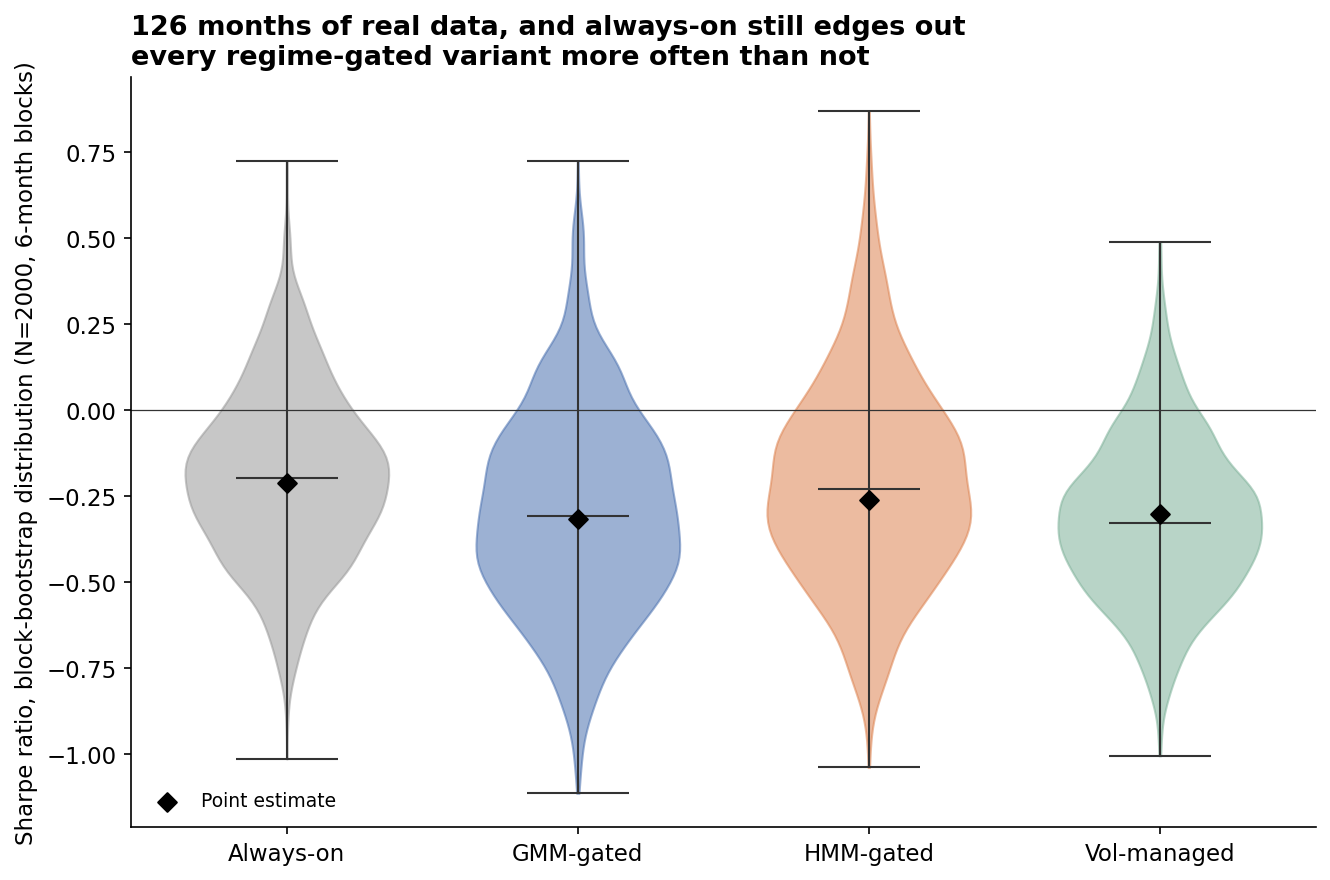

In [12]:
labels = ["Always-on", "GMM-gated", "HMM-gated", "Vol-managed"]
colvals = [GREY, BLUE, ORANGE, GREEN]
fig, ax = plt.subplots(figsize=(9, 6))
parts = ax.violinplot([boot[:, i] for i in range(4)], showmedians=True, widths=0.7)
for pc, c in zip(parts["bodies"], colvals):
    pc.set_facecolor(c); pc.set_alpha(0.55); pc.set_edgecolor(c)
for key in ["cmedians", "cbars", "cmins", "cmaxes"]:
    parts[key].set_color("#333333"); parts[key].set_linewidth(1)
point_est = [mat[:, i].mean() / mat[:, i].std() * np.sqrt(12) for i in range(4)]
ax.scatter(range(1, 5), point_est, color="black", zorder=5, s=40, marker="D", label="Point estimate")
ax.axhline(0, color="#333333", linewidth=0.6)
ax.set_xticks(range(1, 5)); ax.set_xticklabels(labels)
ax.set_ylabel("Sharpe ratio, block-bootstrap distribution (N=2000, 6-month blocks)")
ax.set_title("126 months of real data, and always-on still edges out\nevery regime-gated variant more often than not", loc="left", fontsize=13)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(frameon=False, loc="lower left", fontsize=9)
plt.tight_layout()
plt.savefig("fig3_bootstrap_violin.png", bbox_inches="tight")
plt.show()


## 11. Summary

- **The earlier conclusion reverses on real data.** Always-on carry beats every regime-gated variant on point estimate over 2015-2025, and a block bootstrap gives always-on the edge over each regime method more often than not (P(GMM/HMM/vol-managed > always-on) = 0.33 / 0.45 / 0.13).
- **The mechanism is currency-specific, not a failure of the method in general.** The GMM regime split works exactly as intended for Argentina (calm months averaged +1.03%/month, turbulent months -1.18%). It fails for Turkey, whose carry losses are negative in BOTH regimes -- a continuous structural depreciation, not an episodic crisis a volatility filter can dodge. South Africa and Colombia show the opposite pattern: their "turbulent" months were, in this sample, the profitable ones.
- **A pooled, portfolio-level regime signal averages away this heterogeneity.** The natural next iteration is per-currency regime detection rather than one signal applied to a 7-currency portfolio; Sections 8-9 are the evidence that this is worth doing, not just a suggestion.
- **This version supersedes the hand-reconstructed-rate-table analysis.** Real data changed the answer, not just its precision -- worth remembering before trusting any single backtest's headline number, including this one, without an adversarial check.

**References:** Lustig, H. & Verdelhan, A. (2007); Menkhoff, L., Sarno, L., Schmeling, M. & Schrimpf, A. (2012), *Journal of Finance* 67(2). Moreira, A. & Muir, T. (2017), NBER w22208. Politis, D.N. & Romano, J.P. (1994), "The Stationary Bootstrap," *JASA* 89(428).